|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>Writing the kernel<h1>|
|<h2>Lecture:</h2>|<h1><b>Coalescing: sectors, strides, and a cliff you can predict<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# The arithmetic, before you touch the GPU

A warp holds 32 threads. They issue one load together.

The memory system does not fetch bytes. It fetches **sectors of 32 bytes**.
Ask for one float and you pay for eight.

Now take a warp that reads floats at some stride. Count the sectors that it
needs:

In [2]:
warp = 32          # threads issuing one load together
sector = 32          # bytes the memory system fetches at once
float_bytes =  4          # bytes we actually asked for, per thread

floats_per_sector = sector // float_bytes
print(f'{floats_per_sector} floats live in one sector')

8 floats live in one sector


In [3]:
# stride 1: 32 threads read 32 consecutive floats. 128 bytes, 4 sectors.
# stride 2: they span 64 floats. 256 bytes, 8 sectors, and half is waste.
# stride 8: each thread lands in its own sector. 32 sectors.

for stride in [1,2,4,8,16,32]:
  span_floats = warp * stride
  sectors_read = min(warp, span_floats // floats_per_sector)
  useful = warp / (sectors_read * floats_per_sector)
  print(f'stride {stride:2}:  {sectors_read:2} sectors,  {100*useful:5.1f}% of the bytes used')

stride  1:   4 sectors,  100.0% of the bytes used
stride  2:   8 sectors,   50.0% of the bytes used
stride  4:  16 sectors,   25.0% of the bytes used
stride  8:  32 sectors,   12.5% of the bytes used
stride 16:  32 sectors,   12.5% of the bytes used
stride 32:  32 sectors,   12.5% of the bytes used


The waste stops growing at stride 8. Each thread then owns a sector, and no
waste remains. So strides 8, 16 and 32 must all cost the same.

That is a **prediction**. You can disprove it:

$$\text{useful fraction} = \frac{1}{\min(\text{stride},\ 8)}$$

In [4]:
predicted = {stride: 1/min(stride,8) for stride in [1,2,4,8,16,32]}
predicted

{1: 1.0, 2: 0.5, 4: 0.25, 8: 0.125, 16: 0.125, 32: 0.125}

# Now measure it

You need one kernel and one knob. Each thread reads one float at
`i * stride`.

In [5]:
KERNEL = r"""
#include <ATen/cuda/CUDAContext.h>
#include <c10/cuda/CUDAException.h>
#include <torch/extension.h>

// A pure READ. The store is unreachable, but nvcc cannot prove the value, so
// the load survives. Without it the compiler deletes the kernel and you time
// an empty launch.
__global__ void strided_read(const float* __restrict__ values,
                             float* __restrict__ sink,
                             const long num_threads, const int stride) {
  const long thread = blockIdx.x * (long)blockDim.x + threadIdx.x;
  if (thread >= num_threads) return;
  const float value = values[thread * (long)stride];
  if (value == 1e30f) sink[0] = value;
}

void read_with_stride(torch::Tensor values, torch::Tensor sink,
                      int64_t num_threads, int64_t stride) {
  const int threads_per_block = 256;
  const long num_blocks = (num_threads + threads_per_block - 1) / threads_per_block;
  strided_read<<<num_blocks, threads_per_block, 0,
                 at::cuda::getCurrentCUDAStream()>>>(
      values.data_ptr<float>(), sink.data_ptr<float>(), num_threads, (int)stride);
  C10_CUDA_KERNEL_LAUNCH_CHECK();
}
PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) { m.def("read_with_stride", &read_with_stride); }
"""

extension = cudalib.build_source('nb_stride', KERNEL)

### Design the experiment to measure one thing

Two traps wait here. Each one gives you a confident wrong answer.

1. **Hold the footprint constant, not the thread count.** At stride 1 the
   kernel touches 16 MB. At stride 8 it touches 128 MB. The first fits in L2
   and the second does not. You then measure the cache, not the access
   pattern.
2. **Write nothing.** A kernel that writes one float per thread spends half
   its traffic on the store. That pulls every ratio toward 1.

In [6]:
properties = torch.cuda.get_device_properties(0)
print(f'{properties.name}')
print(f'L2 cache: {properties.L2_cache_size/1e6:.0f} MB')

SPAN = 512 * 1024 * 1024          # ten times the L2, so DRAM serves every read
print(f'footprint: {SPAN/1e6:.0f} MB, held constant at every stride')

values = torch.randn(SPAN//4, device='cuda')
sink = torch.zeros(1, device='cuda')

NVIDIA GeForce RTX 4080 Laptop GPU
L2 cache: 50 MB
footprint: 537 MB, held constant at every stride


In [7]:
strides = [1,2,4,8,16,32]
measured = []

for stride in strides:
  num_threads = SPAN // (4*stride)                  # fewer threads, same footprint
  read_ms = cudalib.bench_ms(lambda: extension.read_with_stride(values,sink,num_threads,stride),
                         iters=30, best_of=3)
  gbs = (num_threads*4) / (read_ms*1e-3) / 1e9      # bytes we WANTED, per second
  measured.append(gbs)
  print(f'stride {stride:2}:  {num_threads:>11,} threads  {gbs:6.0f} GB/s of useful bytes')

stride  1:  134,217,728 threads     328 GB/s of useful bytes
stride  2:   67,108,864 threads     188 GB/s of useful bytes


stride  4:   33,554,432 threads      94 GB/s of useful bytes
stride  8:   16,777,216 threads      47 GB/s of useful bytes


stride 16:    8,388,608 threads      53 GB/s of useful bytes
stride 32:    4,194,304 threads      53 GB/s of useful bytes


# Prediction against measurement

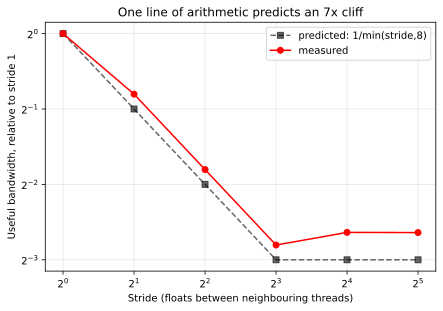

In [8]:
measured_ratios = np.array(measured) / measured[0]
predicted_ratios = np.array([predicted[stride] for stride in strides])

plt.figure(figsize=(7,4.5))
plt.plot(strides, predicted_ratios, 'ks--', label='predicted: 1/min(stride,8)', alpha=.6)
plt.plot(strides, measured_ratios,  'ro-',  label='measured')
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Stride (floats between neighbouring threads)')
plt.ylabel('Useful bandwidth, relative to stride 1')
plt.title('One line of arithmetic predicts an 7x cliff')
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [9]:
for stride,measured_ratio,predicted_ratio in zip(strides, measured_ratios, predicted_ratios):
  print(f'stride {stride:2}:  measured {measured_ratio:.3f}   predicted {predicted_ratio:.3f}   ratio {measured_ratio/predicted_ratio:.2f}')

stride  1:  measured 1.000   predicted 1.000   ratio 1.00
stride  2:  measured 0.573   predicted 0.500   ratio 1.15
stride  4:  measured 0.287   predicted 0.250   ratio 1.15
stride  8:  measured 0.143   predicted 0.125   ratio 1.15
stride 16:  measured 0.161   predicted 0.125   ratio 1.29
stride 32:  measured 0.161   predicted 0.125   ratio 1.28


### Read the difference

The shape is correct. The knee sits exactly where the arithmetic put it. Every
measured point sits a little **above** its prediction, by about the same
factor.

That is not noise. Explain it.

The sector model assumes that the GPU uses each fetched sector once and then
discards it. Sometimes it does not. Two warps can run at the same time and hit
the same sector. L2 then serves the second warp for free.

A model with the correct shape and a constant offset found the mechanism. A
model that hits one point and misses the shape found a coincidence.

# What this costs in a real kernel

Stage 08 gives one thread one context position. The thread then walks
`head_dim` alone. That is the stride-`head_dim` pattern above.

Stage 08b turns the mapping sideways. Each thread then reads an address next
to its neighbour's address. It gains about **2x**, and the arithmetic does not
change at all.

    ./vc guide 8b